# Microscope Design Curves (Unified)

This notebook supersedes:
- `intermediate_lens_magnification_fit.ipynb`
- `condenser_lens_spotsize_fit.ipynb`

It unifies both calibration workflows with a shared minimal core:
- shared transfer-matrix composition (`temgym_core.transfer_matrices`)
- shared scalar root solve helper
- shared focal-to-current and bounds checks

No JSON export is performed. The notebook writes a minimal NPZ design-curve file.

## 1) Config

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import brentq

from temgym_core.transfer_matrices import propagation_matrix, lens_matrix
from temgym_core.constants import compute_Rc_from_voltage

%matplotlib widget

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

U_accel_V = 200e3
Rc_phys = float(compute_Rc_from_voltage(U_accel_V))

# --- Mode A: Condenser ---
geometry_cond = {
    'd_S_C1': 0.2, 'd_C1_C3': 0.04, 'd_C3_A': 10.0e-3,
    'd_A_Cmini': 50.0e-3, 'd_Cmini_OPL': 20.0e-3,
    'f_Cmini': 5.0e-3, 'f_OPL': 5.0e-3,
}

turns_cond         = {'CL1': 3000, 'CL3': 3600}
Gc_phys_cond       = {'CL1': 8.0e-6, 'CL3': 4.0e-6}
I_A_bounds_cond = {'CL1': (0.4, 1.9), 'CL3': (0.4, 1.9)}
AT_bounds_cond = {k: (turns_cond[k] * lo, turns_cond[k] * hi)
                  for k, (lo, hi) in I_A_bounds_cond.items()}

N_spots = 8
f3_scan_points = 2500
sample_rel_tolerance = 2e-2
conjugate_eps = 1e-6

requested_sample_target_min_nm = 500.0
requested_sample_target_max_nm = 5000.0

virtual_source_diameter_nm = 10.0
source_half_angle_mrad = 0.05
sample_distance_from_opl_m = geometry_cond['f_OPL']
source_sigma_x_m     = 0.5 * virtual_source_diameter_nm * 1e-9
source_sigma_theta_rad = source_half_angle_mrad * 1e-3

f_solver_bounds_cond = {'CL1': (0.8e-3, 120.0e-3), 'CL3': (0.8e-3, 900.0e-3)}
enforce_tens_mm_cond = True
f_tens_bounds_cond   = {'CL1': (5.0e-3, 30.0e-3), 'CL3': (5.0e-3, 30.0e-3)}

# --- Mode B: Magnification / Intermediate lens ---
M_obj = 80.0
M_proj = 100.0
target_system_mags = np.array([30000, 50000, 100000, 300000, 600000], dtype=float)
M_mag_targets = target_system_mags / (M_obj * M_proj)
invert_image = True

geometry_proj = {
    'd_il3_to_pl1': 52.0e-3,
    'd_pre_pl1_image_to_pl1': 3.25e-3,
    'd_pl1_to_detector': 0.325,
}
geometry_mag = {
    'd_obj_to_il1': 10e-3, 'd_il1_to_il2': 52e-3,
    'd_il2_to_il3': 62e-3,
    'd_il3_to_image': geometry_proj['d_il3_to_pl1'] - geometry_proj['d_pre_pl1_image_to_pl1'],
}
if not np.isclose(geometry_mag['d_il3_to_image'], 48.75e-3, atol=1e-12):
    raise ValueError('Inconsistent projector geometry: expected d_il3_to_image = 48.75 mm.')
f_pl1_target_m = 1.0 / (
    (1.0 / geometry_proj['d_pre_pl1_image_to_pl1'])
    + (1.0 / geometry_proj['d_pl1_to_detector'])
)
turns_mag       = {'IL1': 3000, 'IL2': 2000, 'IL3': 2000}
Gc_phys_mag     = {'IL1': 8.0e-6, 'IL2': 8.0e-6, 'IL3': 8.0e-6}
reference_i_a_mag = {'IL1': 1.8, 'IL2': 1.8, 'IL3': 1.8}

theta_target = float(sum(Rc_phys * turns_mag[k] * reference_i_a_mag[k] for k in turns_mag))

print(f'Rc_phys={Rc_phys:.4e} rad/AT | theta_target={np.rad2deg(theta_target):.4f} deg')
print(f'Magnification targets: {target_system_mags.astype(int).tolist()} (M_mag={np.round(M_mag_targets, 3).tolist()})')
print(f'Source: {virtual_source_diameter_nm} nm (2σ), {source_half_angle_mrad} mrad')
print(f"Projector distances [mm]: d_IL3_to_image={geometry_mag['d_il3_to_image']*1e3:.3f}, d_IL3_to_PL1={geometry_proj['d_il3_to_pl1']*1e3:.3f}")
print(f'Derived PL1 target focal [mm]: {f_pl1_target_m*1e3:.6f}')

Rc_phys=5.3015e-04 rad/AT | theta_target=382.7299 deg
Magnification targets: [30000, 50000, 100000, 300000, 600000] (M_mag=[3.75, 6.25, 12.5, 37.5, 75.0])
Source: 10.0 nm (2σ), 0.05 mrad


## 2) Shared Physics + Matrix Primitives

In [38]:
def build_chain(elements, xp=np):
    M = xp.eye(3)
    for kind, value in elements:
        if kind == 'P':
            op = propagation_matrix(value, xp=xp)
        elif kind == 'L':
            op = lens_matrix(value, xp=xp)
        else:
            raise ValueError(f'Unknown element kind: {kind}')
        M = op @ M
    return M


def extract_abcd(M):
    return M[0, 0], M[0, 1], M[1, 0], M[1, 1]


def currents_from_focal_lengths(f_map, gc_phys_map, turns_map):
    out = {}
    for k, f in f_map.items():
        if (not np.isfinite(f)) or (f <= 0.0):
            return None
        at = float(np.sqrt(1.0 / (gc_phys_map[k] * f)))
        i_a = float(at / turns_map[k])
        out[f'I_A_{k}'] = i_a
        out[f'AT_{k}'] = at
    return out


def apply_hard_bounds_and_flag(row, i_a_bounds, at_bounds):
    for k, (lo, hi) in i_a_bounds.items():
        v = row[f'I_A_{k}']
        if not (lo <= v <= hi):
            return False
    for k, (lo, hi) in at_bounds.items():
        v = row[f'AT_{k}']
        if not (lo <= v <= hi):
            return False
    return True


def choose_bracket(f_grid, r_grid, prev_root=None):
    finite = np.isfinite(r_grid)
    if not np.any(finite):
        return None

    g = f_grid[finite]
    r = r_grid[finite]

    candidates = []
    for a, b, ra, rb in zip(g[:-1], g[1:], r[:-1], r[1:]):
        if ra == 0.0:
            candidates.append((float(a), float(a)))
        elif ra * rb < 0.0:
            candidates.append((float(a), float(b)))

    if len(candidates) == 0:
        return None

    if prev_root is None:
        return candidates[0]

    mids = np.array([0.5 * (a + b) for (a, b) in candidates], dtype=float)
    j = int(np.argmin(np.abs(mids - prev_root)))
    return candidates[j]


def scalar_root_solve(residual_fn, f_grid, prev_root=None, maxiter=200):
    r_grid = np.array([residual_fn(float(x)) for x in f_grid], dtype=float)
    bracket = choose_bracket(f_grid, r_grid, prev_root=prev_root)

    converged = False
    if bracket is None:
        finite = np.isfinite(r_grid)
        if not np.any(finite):
            raise RuntimeError('No finite residuals in scalar_root_solve')
        g = f_grid[finite]
        r = r_grid[finite]
        root = float(g[np.argmin(np.abs(r))])
    elif bracket[0] == bracket[1]:
        root = float(bracket[0])
        converged = True
    else:
        root = float(brentq(lambda x: residual_fn(float(x)), bracket[0], bracket[1], maxiter=maxiter))
        converged = True

    return root, converged


def focal_bounds_from_current_bounds(gc_phys, turns, i_min, i_max):
    return 1.0 / (gc_phys * (turns * i_max)**2), 1.0 / (gc_phys * (turns * i_min)**2)


f_phys_bounds = {
    k: focal_bounds_from_current_bounds(Gc_phys_cond[k], turns_cond[k], *I_A_bounds_cond[k])
    for k in turns_cond
}
f_bounds_cond = {
    k: (
        max(f_solver_bounds_cond[k][0], f_phys_bounds[k][0]),
        min(f_solver_bounds_cond[k][1], f_phys_bounds[k][1]),
    )
    for k in turns_cond
}
if enforce_tens_mm_cond:
    f_bounds_cond = {
        k: (
            max(f_bounds_cond[k][0], f_tens_bounds_cond[k][0]),
            min(f_bounds_cond[k][1], f_tens_bounds_cond[k][1]),
        )
        for k in turns_cond
    }
    for k, (lo, hi) in f_bounds_cond.items():
        if lo >= hi:
            raise ValueError(f'No feasible focal range for {k}: bounds={f_bounds_cond[k]}')

print(f'Condenser focal bounds [mm]: { {k: tuple(round(1e3*x, 2) for x in v) for k, v in f_bounds_cond.items()} }')

Condenser focal bounds [mm]: {'CL1': (5.0, 30.0), 'CL3': (5.34, 30.0)}


## 3) Mode A: Condenser Spot-Size Design Curves

Inputs: `geometry_cond`, `f_bounds_cond`, source model and electrical bounds. Outputs: `results_cond` list with focal/current curves vs spot index.

In [43]:
def compute_cmini_conjugate_distance(geom, eps):
    d_img_fopl = float(geom['d_Cmini_OPL'] - geom['f_OPL'])
    f_cmini = float(geom['f_Cmini'])
    d_c3_to_cmini = float(geom['d_C3_A'] + geom['d_A_Cmini'])

    if not np.isfinite(d_img_fopl):
        raise ValueError('Invalid d_img_fopl (non-finite).')
    if not (d_img_fopl > f_cmini + eps):
        raise ValueError(
            'Invalid CLmini conjugate geometry: require d_img_fopl > f_Cmini + eps. '
            f'Got d_img_fopl={d_img_fopl:.6e}, f_Cmini={f_cmini:.6e}, eps={eps:.1e}.'
        )

    denom = (1.0 / f_cmini) - (1.0 / d_img_fopl)
    if abs(denom) <= 1e-15:
        raise ValueError('Invalid CLmini conjugate geometry (denominator near zero).')

    d_obj_cmini = 1.0 / denom
    if (not np.isfinite(d_obj_cmini)) or (d_obj_cmini <= 0.0):
        raise ValueError(f'Invalid d_obj_cmini from conjugate calculation: {d_obj_cmini:.6e}.')
    if not (d_obj_cmini < d_c3_to_cmini):
        raise ValueError(
            'Invalid CLmini object-plane location: require d_obj_cmini < d_C3_A + d_A_Cmini.'
        )

    drift_to_ocmini = d_c3_to_cmini - d_obj_cmini
    return float(d_img_fopl), float(d_obj_cmini), float(drift_to_ocmini)


d_img_fopl, d_obj_cmini, drift_to_ocmini = compute_cmini_conjugate_distance(
    geometry_cond,
    conjugate_eps,
    )
print(
    'CLmini conjugate geometry: '
    f'd_img_fopl={d_img_fopl*1e3:.4f} mm, '
    f'd_obj_cmini={d_obj_cmini*1e3:.4f} mm, '
    f'drift_to_Ocmini={drift_to_ocmini*1e3:.4f} mm'
)


def system_matrix_pre(f_cl1, f_cl3, geom, d_obj_cmini_local):
    drift = (geom['d_C3_A'] + geom['d_A_Cmini']) - d_obj_cmini_local
    elems = [
        ('P', geom['d_S_C1']),
        ('L', f_cl1),
        ('P', geom['d_C1_C3']),
        ('L', f_cl3),
        ('P', drift),
    ]
    return build_chain(elems, xp=np)


def system_matrix_cond_to_fopl(f_cl1, f_cl3, geom, d_obj_cmini_local, d_img_fopl_local):
    M_pre = system_matrix_pre(f_cl1, f_cl3, geom, d_obj_cmini_local)
    M_cmini = build_chain([
        ('P', d_obj_cmini_local),
        ('L', geom['f_Cmini']),
        ('P', d_img_fopl_local),
    ], xp=np)
    return M_cmini @ M_pre


def system_matrix_fopl_to_sample(geom, z_sample):
    return build_chain([
        ('P', geom['f_OPL']),
        ('L', geom['f_OPL']),
        ('P', z_sample),
    ], xp=np)


def q_inv_from_source_model(sigma_x_m, sigma_theta_rad, wavelength_m):
    if not (np.isfinite(sigma_x_m) and sigma_x_m > 0.0):
        raise ValueError(f'Invalid sigma_x_m={sigma_x_m}')
    if not (np.isfinite(sigma_theta_rad) and sigma_theta_rad > 0.0):
        raise ValueError(f'Invalid sigma_theta_rad={sigma_theta_rad}')
    if not (np.isfinite(wavelength_m) and wavelength_m > 0.0):
        raise ValueError(f'Invalid wavelength_m={wavelength_m}')

    # Intensity Gaussian convention: sigma_x = w / 2.
    w = 2.0 * sigma_x_m
    q_inv_im = wavelength_m / (np.pi * w * w)

    # sigma_theta^2 = sigma_theta_diff^2 + sigma_theta_curv^2
    sigma_theta_diff = wavelength_m / (2.0 * np.pi * w)
    sigma_theta_curv_sq = max(sigma_theta_rad * sigma_theta_rad - sigma_theta_diff * sigma_theta_diff, 0.0)

    if sigma_theta_curv_sq <= 0.0:
        q_inv_re = 0.0
    else:
        sigma_theta_curv = float(np.sqrt(sigma_theta_curv_sq))
        q_inv_re = sigma_theta_curv / sigma_x_m

    return complex(q_inv_re, q_inv_im)


def propagate_q_inv_abcd(q_inv_in, M_2x2, tiny=1e-15):
    A, B = float(M_2x2[0, 0]), float(M_2x2[0, 1])
    C, D = float(M_2x2[1, 0]), float(M_2x2[1, 1])

    denom = A + B * q_inv_in
    if abs(denom) <= tiny:
        return None
    return (C + D * q_inv_in) / denom


def fwhm_from_q_inv(q_inv_out, wavelength_m):
    q_inv_im = float(np.imag(q_inv_out))
    if not (np.isfinite(q_inv_im) and q_inv_im > 0.0):
        return np.inf

    w = np.sqrt(wavelength_m / (np.pi * q_inv_im))
    fwhm = w * np.sqrt(2.0 * np.log(2.0))
    return float(fwhm)


def lens_image_distance(f_lens, s_object, tiny=1e-15):
    denom = (1.0 / f_lens) - (1.0 / s_object)
    if abs(denom) <= tiny:
        return None
    s_image = 1.0 / denom
    if not np.isfinite(s_image):
        return None
    return float(s_image)


def enforce_staged_real_imaging(f_cl1, f_cl3, geom, d_obj_cmini_local, residual_tol=1e-5, tiny=1e-12):
    s1 = float(geom['d_S_C1'])
    d12 = float(geom['d_C1_C3'])
    s3p = float((geom['d_C3_A'] + geom['d_A_Cmini']) - d_obj_cmini_local)

    if min(s1, d12, s3p) <= tiny:
        return None

    s1p = lens_image_distance(f_cl1, s1, tiny=tiny)
    if (s1p is None) or (s1p <= tiny):
        return None
    if not (s1p < d12 - tiny):
        return None

    s3 = float(d12 - s1p)
    if s3 <= tiny:
        return None

    inv_f3 = 1.0 / f_cl3
    inv_s3 = 1.0 / s3
    inv_s3p = 1.0 / s3p
    r3 = inv_f3 - inv_s3 - inv_s3p

    scale = max(abs(inv_f3), abs(inv_s3) + abs(inv_s3p), 1.0)
    if abs(r3) > residual_tol * scale:
        return None

    M_joint = build_chain([
        ('P', s1),
        ('L', f_cl1),
        ('P', d12),
        ('L', f_cl3),
        ('P', s3p),
    ], xp=np)
    _, B_joint, _, _ = extract_abcd(M_joint)

    return {
        's1_obj_m': float(s1),
        's1_img_m': float(s1p),
        's3_obj_m': float(s3),
        's3_img_m': float(s3p),
        'r3_residual': float(r3),
        'B_joint': float(B_joint),
    }


imaging_residual_tol = 1e-5


lambda_e_m = float(12.264306e-10 / np.sqrt(U_accel_V * (1.0 + 0.978466e-6 * U_accel_V)))
q_inv_source = q_inv_from_source_model(source_sigma_x_m, source_sigma_theta_rad, lambda_e_m)
print(
    f'Source q_inv: Re={np.real(q_inv_source):.6e} 1/m, '
    f'Im={np.imag(q_inv_source):.6e} 1/m (lambda={lambda_e_m*1e12:.4f} pm)'
)


M_fopl_to_sample = system_matrix_fopl_to_sample(geometry_cond, sample_distance_from_opl_m)
A_fs, B_fs, _, _ = extract_abcd(M_fopl_to_sample)
print(f'F_OPL -> sample: A={float(A_fs):.6e}, B={float(B_fs):.6e} m/rad')


def f1_from_f3_numeric_pre(f3, geom, f1_lo, f1_hi, d_obj_cmini_local, n_scan=500):
    f1_grid = np.geomspace(f1_lo, f1_hi, int(n_scan))

    def b_pre_of_f1(x):
        M_pre = system_matrix_pre(x, f3, geom, d_obj_cmini_local)
        _, B_pre, _, _ = extract_abcd(M_pre)
        return float(B_pre)

    root, _ = scalar_root_solve(b_pre_of_f1, f1_grid, prev_root=None, maxiter=200)
    return float(root)


def evaluate_candidate_cond(f3, geom, f_bounds_local, d_obj_cmini_local, d_img_fopl_local):
    if not np.isfinite(f3) or f3 <= 0:
        return None
    if not (f_bounds_local['CL3'][0] <= f3 <= f_bounds_local['CL3'][1]):
        return None

    f1 = f1_from_f3_numeric_pre(
        f3,
        geom,
        f_bounds_local['CL1'][0],
        f_bounds_local['CL1'][1],
        d_obj_cmini_local,
    )
    if not np.isfinite(f1) or f1 <= 0:
        return None
    if not (f_bounds_local['CL1'][0] <= f1 <= f_bounds_local['CL1'][1]):
        return None

    staged = enforce_staged_real_imaging(
        f1,
        f3,
        geom,
        d_obj_cmini_local,
        residual_tol=imaging_residual_tol,
    )
    if staged is None:
        return None

    M_pre = system_matrix_pre(f1, f3, geom, d_obj_cmini_local)
    A_pre, B_pre, _, _ = extract_abcd(M_pre)

    M_sfopl = system_matrix_cond_to_fopl(f1, f3, geom, d_obj_cmini_local, d_img_fopl_local)
    A_fopl, B_fopl, _, _ = extract_abcd(M_sfopl)

    M_total = M_fopl_to_sample @ M_sfopl
    M_total_2x2 = np.asarray(M_total[:2, :2], dtype=float)

    q_inv_sample = propagate_q_inv_abcd(q_inv_source, M_total_2x2)
    if q_inv_sample is None:
        return None

    fwhm_sample_nm = float(fwhm_from_q_inv(q_inv_sample, lambda_e_m) * 1e9)
    if not np.isfinite(fwhm_sample_nm):
        return None

    cur = currents_from_focal_lengths(
        {'CL1': f1, 'CL3': f3},
        Gc_phys_cond,
        turns_cond,
    )
    if cur is None:
        return None
    if not apply_hard_bounds_and_flag(cur, I_A_bounds_cond, AT_bounds_cond):
        return None

    out = {
        'f_CL1': float(f1),
        'f_CL3': float(f3),
        'A_pre_abs': float(abs(A_pre)),
        'A_fopl_abs': float(abs(A_fopl)),
        'B_pre': float(B_pre),
        'B_fopl': float(B_fopl),
        'fwhm_sample_nm': fwhm_sample_nm,
        'q_inv_sample_re_1pm': float(np.real(q_inv_sample) * 1e-12),
        'q_inv_sample_im_1pm': float(np.imag(q_inv_sample) * 1e-12),
        'd_obj_cmini': float(d_obj_cmini_local),
        's1_img_mm': float(staged['s1_img_m'] * 1e3),
        's3_obj_mm': float(staged['s3_obj_m'] * 1e3),
        's3_img_mm': float(staged['s3_img_m'] * 1e3),
        'r3_residual': float(staged['r3_residual']),
        'B_joint_residual': float(staged['B_joint']),
    }
    out.update(cur)
    return out


f3_grid = np.geomspace(f_bounds_cond['CL3'][0], f_bounds_cond['CL3'][1], int(f3_scan_points))
feasible = []
for f3 in f3_grid:
    cand = evaluate_candidate_cond(float(f3), geometry_cond, f_bounds_cond, d_obj_cmini, d_img_fopl)
    if cand is not None:
        feasible.append(cand)

if len(feasible) < N_spots:
    raise RuntimeError(
        f'Insufficient feasible candidates ({len(feasible)}) for N_spots={N_spots}. '
        'Relax geometry or electrical bounds.'
    )

feasible_sorted = sorted(feasible, key=lambda r: r['f_CL3'])
f3_scan = np.array([r['f_CL3'] for r in feasible_sorted], dtype=float)
fwhm_sample_scan_nm = np.array([r['fwhm_sample_nm'] for r in feasible_sorted], dtype=float)

candidate_cache = {float(r['f_CL3']): r for r in feasible_sorted}

def get_candidate_cached(f3):
    key = float(f3)
    if key in candidate_cache:
        return candidate_cache[key]
    c = evaluate_candidate_cond(key, geometry_cond, f_bounds_cond, d_obj_cmini, d_img_fopl)
    if c is not None:
        candidate_cache[key] = c
    return c

def fwhm_sample_interp_nm(f3):
    return float(np.interp(float(f3), f3_scan, fwhm_sample_scan_nm))


def resolve_sample_targets(feasible_nm, req_min_nm, req_max_nm, n_spots):
    feas_min = float(np.min(feasible_nm))
    feas_max = float(np.max(feasible_nm))
    lo = max(float(req_min_nm), feas_min)
    hi = min(float(req_max_nm), feas_max)

    return np.geomspace(lo, hi, int(n_spots)), 'requested_overlap'


sample_targets_nm, sample_target_mode_used = resolve_sample_targets(
    fwhm_sample_scan_nm,
    requested_sample_target_min_nm,
    requested_sample_target_max_nm,
    N_spots,
    )
print(f'sample target mode used: {sample_target_mode_used}')
print('sample FWHM targets [nm]:', np.array2string(sample_targets_nm, precision=3))


results_cond = []
prev_root = None

for i, d_t_nm in enumerate(sample_targets_nm, start=1):
    def residual_sample_interp(x):
        return fwhm_sample_interp_nm(x) - d_t_nm

    root_f3, converged = scalar_root_solve(residual_sample_interp, f3_scan, prev_root=prev_root, maxiter=200)
    c = get_candidate_cached(root_f3)
    if c is None:
        raise RuntimeError(f'Invalid physics candidate at spot {i}')

    d_err_abs = float(c['fwhm_sample_nm'] - d_t_nm)
    d_err_rel = float(d_err_abs / d_t_nm)
    converged_final = bool(converged or (abs(d_err_rel) <= sample_rel_tolerance))

    results_cond.append({
        'spot_index': int(i),
        'fwhm_sample_target_nm': float(d_t_nm),
        'fwhm_sample_solved_nm': float(c['fwhm_sample_nm']),
        'fwhm_sample_err_abs_nm': d_err_abs,
        'fwhm_sample_err_rel': d_err_rel,
        'A_pre_abs': float(c['A_pre_abs']),
        'A_fopl_abs': float(c['A_fopl_abs']),
        'B_pre_residual': float(c['B_pre']),
        'B_fopl_residual': float(c['B_fopl']),
        'sample_target_mode': sample_target_mode_used,
        'f_CL1': float(c['f_CL1']),
        'f_CL3': float(c['f_CL3']),
        'I_A_CL1': float(c['I_A_CL1']),
        'I_A_CL3': float(c['I_A_CL3']),
        'AT_CL1': float(c['AT_CL1']),
        'AT_CL3': float(c['AT_CL3']),
        'q_inv_sample_re_1pm': float(c['q_inv_sample_re_1pm']),
        'q_inv_sample_im_1pm': float(c['q_inv_sample_im_1pm']),
        's1_img_mm': float(c['s1_img_mm']),
        's3_obj_mm': float(c['s3_obj_mm']),
        's3_img_mm': float(c['s3_img_mm']),
        'r3_residual': float(c['r3_residual']),
        'B_joint_residual': float(c['B_joint_residual']),
        'converged': converged_final,
    })
    prev_root = root_f3

print(f'Solved condenser points: {len(results_cond)}')
print(f'Converged: {sum(int(r["converged"]) for r in results_cond)}/{len(results_cond)}')

print([r['s1_img_mm'] for r in results_cond])

CLmini conjugate geometry: d_img_fopl=15.0000 mm, d_obj_cmini=7.5000 mm, drift_to_Ocmini=52.5000 mm
Source q_inv: Re=6.022549e+03 1/m, Im=7.983039e+03 1/m (lambda=2.5079 pm)
F_OPL -> sample: A=-2.081668e-17, B=5.000000e-03 m/rad
sample target mode used: requested_overlap
sample FWHM targets [nm]: [ 500.     694.748  965.349 1341.348 1863.797 2589.737 3598.428 5000.   ]
Solved condenser points: 8
Converged: 8/8
[27.744441971265672, 24.745009402365124, 21.52231406065231, 18.22889141832591, 15.034766016388998, 12.09195796068458, 9.506937927292011, 7.329880555185978]


## 4) Mode B: Magnification (Intermediate Lens) Design Curves

Inputs: `geometry_mag`, `M_mag_targets`, and `theta_target`. Outputs: `mag_results` list with focal/current curves vs system magnification.

In [40]:
def system_matrix_il(f1, f2, f3, geom):
    elems = [
        ('P', geom['d_obj_to_il1']),
        ('L', f1),
        ('P', geom['d_il1_to_il2']),
        ('L', f2),
        ('P', geom['d_il2_to_il3']),
        ('L', f3),
        ('P', geom['d_il3_to_image']),
    ]
    return build_chain(elems, xp=np)


def f2_from_f3_A(f3, A, geom):
    d01 = geom['d_obj_to_il1']
    d12 = geom['d_il1_to_il2']
    d23 = geom['d_il2_to_il3']
    d3i = geom['d_il3_to_image']
    num = d12 * (f3 * (d23 + d3i) - d23 * d3i)
    den = f3 * (A * d01 + d23 + d3i + d12) - d3i * (d23 + d12)
    return np.nan if abs(den) < 1e-15 else num / den


def f1_from_f3_A(f3, A, geom):
    d01 = geom['d_obj_to_il1']
    d12 = geom['d_il1_to_il2']
    d23 = geom['d_il2_to_il3']
    d3i = geom['d_il3_to_image']
    num = A * d01 * d12 * f3
    den = f3 * (A * (d01 + d12) + d23 + d3i) - d23 * d3i
    return np.nan if abs(den) < 1e-15 else num / den


def theta_residual_f3(f3, A, theta_target_local, geom, gc_phys, turns):
    f2 = f2_from_f3_A(f3, A, geom)
    f1 = f1_from_f3_A(f3, A, geom)
    if not np.all(np.isfinite([f1, f2])) or min(f1, f2, f3) <= 0.0:
        return np.nan

    cur = currents_from_focal_lengths(
        {'IL1': f1, 'IL2': f2, 'IL3': f3},
        gc_phys,
        turns,
    )
    if cur is None:
        return np.nan

    theta_sum = Rc_phys * (cur['AT_IL1'] + cur['AT_IL2'] + cur['AT_IL3'])
    return float(theta_sum - theta_target_local)


def solve_one_target_mag(m_mag, theta_target_local, geom, gc_phys, turns, invert=True,
                         f3_min=1e-3, f3_max=80e-3, n_grid=4000):
    A_target = -float(m_mag) if invert else float(m_mag)
    f3_grid = np.geomspace(f3_min, f3_max, int(n_grid))

    def residual(x):
        return theta_residual_f3(float(x), A_target, theta_target_local, geom, gc_phys, turns)

    f3_star, converged = scalar_root_solve(residual, f3_grid, prev_root=None)

    f2_star = float(f2_from_f3_A(f3_star, A_target, geom))
    f1_star = float(f1_from_f3_A(f3_star, A_target, geom))
    if min(f1_star, f2_star, f3_star) <= 0.0 or not np.all(np.isfinite([f1_star, f2_star, f3_star])):
        raise RuntimeError(f'Non-physical solution for M_mag={m_mag:.4g}')

    cur = currents_from_focal_lengths(
        {'IL1': f1_star, 'IL2': f2_star, 'IL3': f3_star},
        gc_phys,
        turns,
    )
    theta_sum = float(Rc_phys * (cur['AT_IL1'] + cur['AT_IL2'] + cur['AT_IL3']))

    M = system_matrix_il(f1_star, f2_star, f3_star, geom)
    A_actual, B_actual, _, _ = extract_abcd(M)

    return {
        'M_mag': float(m_mag),
        'A_actual': float(A_actual),
        'B_m': float(B_actual),
        'f1_m': float(f1_star),
        'f2_m': float(f2_star),
        'f3_m': float(f3_star),
        'I1_A': float(cur['I_A_IL1']),
        'I2_A': float(cur['I_A_IL2']),
        'I3_A': float(cur['I_A_IL3']),
        'AT1': float(cur['AT_IL1']),
        'AT2': float(cur['AT_IL2']),
        'AT3': float(cur['AT_IL3']),
        'theta_err': float(theta_sum - theta_target_local),
        'converged': bool(converged),
    }


def solve_series_mag(mag_targets):
    out = []
    for m_mag in np.asarray(mag_targets, dtype=float):
        out.append(
            solve_one_target_mag(
                m_mag=m_mag,
                theta_target_local=theta_target,
                geom=geometry_mag,
                gc_phys=Gc_phys_mag,
                turns=turns_mag,
                invert=invert_image,
            )
        )
    return out


mag_results = solve_series_mag(M_mag_targets)
print(f'Solved magnification points: {len(mag_results)}')
print(f'Exact root brackets: {sum(int(r["converged"]) for r in mag_results)}/{len(mag_results)}')

Solved magnification points: 5
Exact root brackets: 5/5


## 5) Curves + Minimal Design-Curve Export

Plots the four main design curves (condenser focals/currents and intermediate focals/currents),
then exports only minimal design-curve arrays: control variable, lens focal(s), and unnormalized current(s) in amps.

No microscope metadata, no `Gc` scales, and no interpolated/dense fit curves are saved.

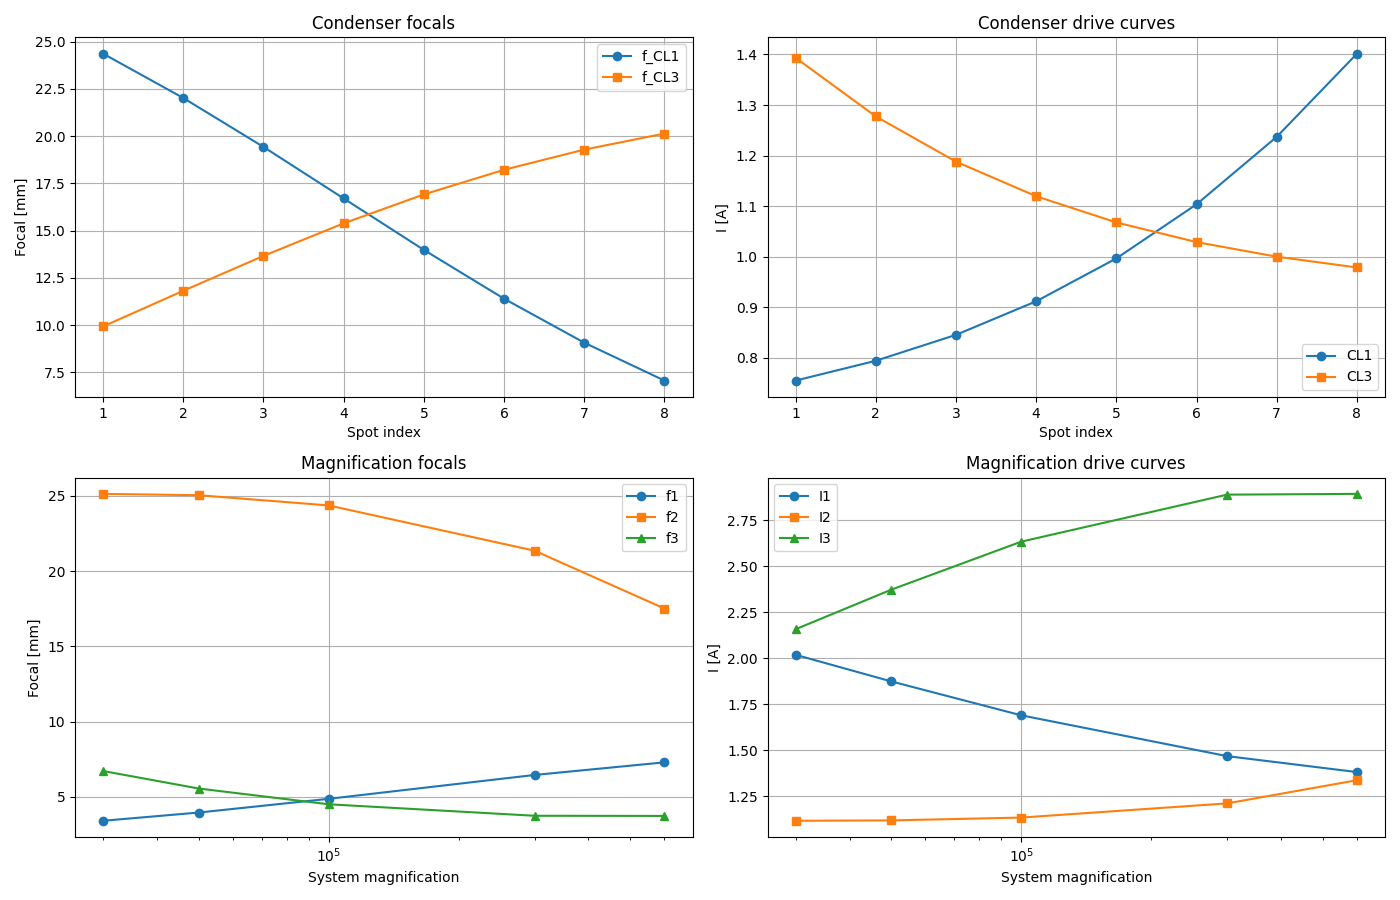

Exported minimal design curves: /home/dl277493/Documents/Code/TemGymCore/examples/microscope_models/data/microscope_design_curves.npz


In [44]:
# --- Four curve plots ---
spot_idx = np.array([r['spot_index'] for r in results_cond], dtype=float)
f_cl1_mm = np.array([r['f_CL1'] for r in results_cond], dtype=float) * 1e3
f_cl3_mm = np.array([r['f_CL3'] for r in results_cond], dtype=float) * 1e3
i_cl1_a = np.array([r['I_A_CL1'] for r in results_cond], dtype=float)
i_cl3_a = np.array([r['I_A_CL3'] for r in results_cond], dtype=float)

x_sys = np.array(target_system_mags, dtype=float)
f1_mag_mm = np.array([r['f1_m'] for r in mag_results], dtype=float) * 1e3
f2_mag_mm = np.array([r['f2_m'] for r in mag_results], dtype=float) * 1e3
f3_mag_mm = np.array([r['f3_m'] for r in mag_results], dtype=float) * 1e3
i1_mag_a = np.array([r['I1_A'] for r in mag_results], dtype=float)
i2_mag_a = np.array([r['I2_A'] for r in mag_results], dtype=float)
i3_mag_a = np.array([r['I3_A'] for r in mag_results], dtype=float)

fig, axs = plt.subplots(2, 2, figsize=(14, 9))

axs[0, 0].plot(spot_idx, f_cl1_mm, 'o-', label='f_CL1')
axs[0, 0].plot(spot_idx, f_cl3_mm, 's-', label='f_CL3')
axs[0, 0].set(title='Condenser focals', xlabel='Spot index', ylabel='Focal [mm]')
axs[0, 0].legend()

axs[0, 1].plot(spot_idx, i_cl1_a, 'o-', label='CL1')
axs[0, 1].plot(spot_idx, i_cl3_a, 's-', label='CL3')
axs[0, 1].set(title='Condenser drive curves', xlabel='Spot index', ylabel='I [A]')
axs[0, 1].legend()

axs[1, 0].semilogx(x_sys, f1_mag_mm, 'o-', label='f1')
axs[1, 0].semilogx(x_sys, f2_mag_mm, 's-', label='f2')
axs[1, 0].semilogx(x_sys, f3_mag_mm, '^-', label='f3')
axs[1, 0].set(title='Magnification focals', xlabel='System magnification', ylabel='Focal [mm]')
axs[1, 0].legend()

axs[1, 1].semilogx(x_sys, i1_mag_a, 'o-', label='I1')
axs[1, 1].semilogx(x_sys, i2_mag_a, 's-', label='I2')
axs[1, 1].semilogx(x_sys, i3_mag_a, '^-', label='I3')
axs[1, 1].set(title='Magnification drive curves', xlabel='System magnification', ylabel='I [A]')
axs[1, 1].legend()

fig.tight_layout()
plt.show()

# --- ObjPost / PL1 compensation current curves ---
turns_objpost = 3000.0
turns_pl1 = 2000.0
Gc_objpost = 8.0e-6
Gc_pl1 = 8.0e-6
comp_sign = -1.0  # oppose IL rotation sign

ni_mag_total = np.array([r['AT1'] + r['AT2'] + r['AT3'] for r in mag_results], dtype=float)

# Constrain PL1 to projector geometry, then use ObjPost as residual to cancel total rotation.
ni_pl1_target_mag = np.sqrt(1.0 / (Gc_pl1 * f_pl1_target_m))
ni_pl1 = np.full(ni_mag_total.shape, comp_sign * ni_pl1_target_mag, dtype=float)
ni_objpost = -ni_mag_total - ni_pl1

i_a_objpost = ni_objpost / turns_objpost
i_a_pl1 = ni_pl1 / turns_pl1

f_pl1_from_current = 1.0 / (Gc_pl1 * (turns_pl1 * i_a_pl1)**2)
if not np.allclose(f_pl1_from_current, f_pl1_target_m, rtol=1e-12, atol=1e-12):
    raise RuntimeError('PL1 current does not realize target focal length.')

net_ni = ni_mag_total + ni_objpost + ni_pl1
if not np.allclose(net_ni, 0.0, atol=1e-9):
    raise RuntimeError('ObjPost/PL1 compensation does not cancel IL NI total.')

print(f'Compensation currents [ObjPost, PL1] at first point [A]: {i_a_objpost[0]:.6f}, {i_a_pl1[0]:.6f}')

# --- Export minimal design curves only ---
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'src').exists()), cwd)
export_path = repo_root / 'examples/microscope_models/data/microscope_design_curves.npz'
export_path.parent.mkdir(parents=True, exist_ok=True)

spot_control_values = np.array([r['spot_index'] for r in results_cond], dtype=float)
spot_lens_focals_m = np.column_stack([
    [r['f_CL1'] for r in results_cond],
    [r['f_CL3'] for r in results_cond],
])
spot_currents_a = np.column_stack([
    [r['I_A_CL1'] for r in results_cond],
    [r['I_A_CL3'] for r in results_cond],
])

mag_control_values = np.array(target_system_mags, dtype=float)
mag_lens_focals_m = np.column_stack([
    [r['f1_m'] for r in mag_results],
    [r['f2_m'] for r in mag_results],
    [r['f3_m'] for r in mag_results],
])
mag_currents_a_il = np.column_stack([
    [r['I1_A'] for r in mag_results],
    [r['I2_A'] for r in mag_results],
    [r['I3_A'] for r in mag_results],
])
mag_currents_a_comp = np.column_stack([i_a_objpost, i_a_pl1])

np.savez(
    export_path,
    spot_control_values=spot_control_values,
    spot_lens_focals_m=spot_lens_focals_m,
    spot_currents_a=spot_currents_a,
    mag_control_values=mag_control_values,
    mag_lens_focals_m=mag_lens_focals_m,
    mag_currents_a_il=mag_currents_a_il,
    mag_currents_a_comp=mag_currents_a_comp,
)
print(f'Exported minimal design curves: {export_path}')